**Calculating physicochemical properties of key capping agents from Mangifera indica leaf extract for computational modeling of Cu-Ag nanoparticles**

In [5]:
!pip install rdkit

In [25]:
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import Descriptors
import pandas as pd

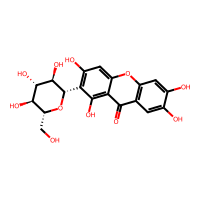

{name} is valid
Molecular Weight: 422.34
LogP: -0.72
Number of Hydrogen Bonds: 8
Number of Hydrogen Bonds: 11


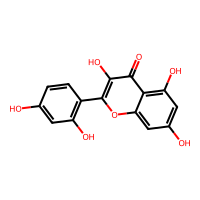

{name} is valid
Molecular Weight: 302.24
LogP: 1.99
Number of Hydrogen Bonds: 5
Number of Hydrogen Bonds: 7


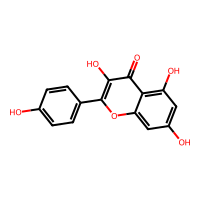

{name} is valid
Molecular Weight: 286.24
LogP: 2.28
Number of Hydrogen Bonds: 4
Number of Hydrogen Bonds: 6


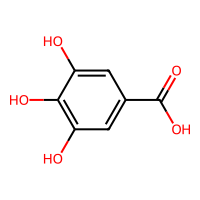

{name} is valid
Molecular Weight: 170.12
LogP: 0.50
Number of Hydrogen Bonds: 4
Number of Hydrogen Bonds: 4
Ellagic acid is invalid


In [16]:
Molecules = {
    'Mangiferin': 'C1=C2C(=CC(=C1O)O)OC3=C(C2=O)C(=C(C(=C3)O)[C@H]4[C@@H]([C@H]([C@@H]([C@H](O4)CO)O)O)O)O',
    'Quercetin': 'Oc1ccc(c(O)c1)c2oc3cc(O)cc(O)c3c(=O)c2O',
    'Kaempferol': 'Oc1ccc(cc1)c2oc3cc(O)cc(O)c3c(=O)c2O',
    'Gallic acid': 'OC(=O)c1cc(O)c(O)c(O)c1',
    'Ellagic acid': 'Oc1cc2c3c(O1)c(=O)oc4cc(O)c(O)c(c43)c(=O)o2'
}
for name, smiles in Molecules.items():
  mol= Chem.MolFromSmiles(smiles)
  if mol is not None:  #calling the molecule images
    img = Draw.MolToImage(mol, size=(200,200))
    display(img)
    print('{name} is valid')
    #writing out the properties of the molecule.
    print(f'Molecular Weight: {Descriptors.MolWt(mol):.2f}')
    print(f'LogP: {Descriptors.MolLogP(mol):.2f}')
    print(f'Number of Hydrogen Bonds: {Descriptors.NumHDonors(mol)}')
    print(f'Number of Hydrogen Bonds: {Descriptors.NumHAcceptors(mol)}')
  else:
    print(f'{name} is invalid')

In [26]:
Molecules = [{'name':'Mangiferin', 'smiles': 'C1=C2C(=CC(=C1O)O)OC3=C(C2=O)C(=C(C(=C3)O)[C@H]4[C@@H]([C@H]([C@@H]([C@H](O4)CO)O)O)O)O'},
    {'name':'Quercetin', 'smiles': 'Oc1ccc(c(O)c1)c2oc3cc(O)cc(O)c3c(=O)c2O'},
    {'name':'Kaempferol', 'smiles': 'Oc1ccc(cc1)c2oc3cc(O)cc(O)c3c(=O)c2O'},
    {'name':'Gallic acid', 'smiles': 'OC(=O)c1cc(O)c(O)c(O)c1'},
    {'name':'Ellagic acid', 'smiles': 'Oc1cc2c3c(O1)c(=O)oc4cc(O)c(O)c(c43)c(=O)o2'}]
Molecules_list=[]
for mol in Molecules:
  name = mol['name']
  smiles = mol['smiles']
  mol_obj = Chem.MolFromSmiles(smiles) # Renamed 'mol' to 'mol_obj' to avoid conflict with loop variable
  if mol_obj is not None:
    data = {
        'name': name,
        'Molecular Weight': f"{Descriptors.MolWt(mol_obj):.2f}",
        'LogP': f"{Descriptors.MolLogP(mol_obj):.2f}",
        'Number of Hydrogen Bonds Donor': Descriptors.NumHDonors(mol_obj),
        'Number of Hydrogen Bonds Acceptor': Descriptors.NumHAcceptors(mol_obj)
    }
    Molecules_list.append(data)
df = pd.DataFrame(Molecules_list)
df


,name,Molecular Weight,LogP,Number of Hydrogen Bonds Donor,Number of Hydrogen Bonds Acceptor
0,Mangiferin,422.34,-0.72,8,11
1,Quercetin,302.24,1.99,5,7
2,Kaempferol,286.24,2.28,4,6
3,Gallic acid,170.12,0.50,4,4
